# ==========================================================
# Breast Cancer Survival Prediction using Apache Spark
# Notebook 05: Advanced Model Evaluation
# ==========================================================

"""
Objective
---------
1. Load trained models and preprocessing pipelines.
2. Load the testing dataset generated in Notebook 04.
3. Generate predictions using all trained models.
4. Evaluate model performance using multiple metrics.
5. Compare models through visualizations.
6. Rank candidate models.
7. Select the best-performing model for interpretation.

Mục tiêu
---------
1. Nạp các mô hình và Pipeline đã huấn luyện.
2. Nạp tập kiểm thử được tạo từ Notebook 04.
3. Thực hiện dự đoán bằng tất cả các mô hình.
4. Đánh giá hiệu năng bằng nhiều chỉ số khác nhau.
5. So sánh các mô hình thông qua trực quan hóa.
6. Xếp hạng các mô hình.
7. Lựa chọn mô hình tốt nhất phục vụ diễn giải.
"""

In [1]:
# 1. Import Libraries | Khai báo thư viện 

print("=" * 60)
print("1. IMPORT LIBRARIES")
print("=" * 60)

import os
import sys
import pandas as pd

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.ml import PipelineModel
from pyspark.ml.classification import (
    LogisticRegressionModel, DecisionTreeClassificationModel, 
    RandomForestClassificationModel, GBTClassificationModel
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

from src.data.loader import create_spark_session

1. IMPORT LIBRARIES


In [2]:
# 2. Create Spark Session | Khởi tạo Spark Session

print("\n" + "=" * 60)
print("2. CREATE SPARK SESSION")
print("=" * 60)

spark = create_spark_session("SEER Breast Cancer Model Evaluation")


2. CREATE SPARK SESSION


In [3]:
# 3. Define Project Paths | Định nghĩa đường dẫn

print("\n" + "=" * 60)
print("3. DEFINE PROJECT PATHS")
print("=" * 60)

MODEL_PATH = "../models/trained_models"
DATA_PATH = "../data/processed/test_dataset.parquet"

REPORT_PATH = "../reports"

FIGURE_PATH = os.path.join(REPORT_PATH, "figures")
TABLE_PATH = os.path.join(REPORT_PATH, "tables")

BEST_MODEL_PATH = "../models/best_model.txt"

linear_pipeline_path = os.path.join(MODEL_PATH,"logistic_regression_pipeline")

tree_pipeline_path = os.path.join(MODEL_PATH,"tree_models_pipeline")

os.makedirs(FIGURE_PATH, exist_ok=True)
os.makedirs(TABLE_PATH, exist_ok=True)

print(f"Model Path     : {MODEL_PATH}")
print(f"Best Model File : {BEST_MODEL_PATH}")
print(f"Dataset Path   : {DATA_PATH}")
print(f"Linear Pipeline: {linear_pipeline_path}")
print(f"Tree Pipeline  : {tree_pipeline_path}")


3. DEFINE PROJECT PATHS
Model Path     : ../models/trained_models
Best Model File : ../models/best_model.txt
Dataset Path   : ../data/processed/test_dataset.parquet
Linear Pipeline: ../models/trained_models\logistic_regression_pipeline
Tree Pipeline  : ../models/trained_models\tree_models_pipeline


In [4]:
# 4. Load Testing Dataset | Nạp tập dữ liệu kiểm thử

from pyspark.sql import functions as F

print("\n" + "=" * 60)
print("4. LOAD TEST DATASET")
print("=" * 60)

test_df = spark.read.parquet(DATA_PATH)
if "weight" not in test_df.columns:
    test_df = test_df.withColumn("weight", F.lit(1.0))

print(f"Testing Dataset Loaded | Rows: {test_df.count():,}")


4. LOAD TEST DATASET
Testing Dataset Loaded | Rows: 90,756


In [5]:
# 5. Load Saved Pipelines | Tải Pipeline tiền xử lý

print("\n" + "=" * 60)
print("5. LOAD SAVED PIPELINES")
print("=" * 60)

def spark_local_path(path):
    path = os.path.abspath(path)
    return "file:///" + path.replace("\\", "/")

linear_pipeline = PipelineModel.load(spark_local_path(linear_pipeline_path))

tree_pipeline = PipelineModel.load(spark_local_path(tree_pipeline_path))

print("Linear preprocessing pipeline loaded.")
print("Tree preprocessing pipeline loaded.")


5. LOAD SAVED PIPELINES
Linear preprocessing pipeline loaded.
Tree preprocessing pipeline loaded.


In [6]:
# 6. Load Trained Models | Tải mô hình đã huấn luyện

print("\n" + "=" * 60)
print("6. LOAD TRAINED MODELS")
print("=" * 60)

lr_model = LogisticRegressionModel.load(
    spark_local_path(os.path.join(MODEL_PATH,"logistic_regression_model"))
)

dt_model = DecisionTreeClassificationModel.load(
    spark_local_path(os.path.join(MODEL_PATH,"decision_tree_model"))
)

rf_model = RandomForestClassificationModel.load(
    spark_local_path(os.path.join(MODEL_PATH,"random_forest_model"))
)

gbt_model = GBTClassificationModel.load(
    spark_local_path(os.path.join(MODEL_PATH,"gbt_classifier_model"))
)

print("Models loaded successfully.")


6. LOAD TRAINED MODELS
Models loaded successfully.


In [7]:
# 7. Prepare Evaluation Dataset | Chuẩn bị dữ liệu đánh giá

print("\n" + "=" * 60)
print("7. PREPARE EVALUATION DATASET")
print("=" * 60)

test_linear = linear_pipeline.transform(test_df)
test_tree = tree_pipeline.transform(test_df)
print("Evaluation datasets transformed via Pipelines.")


7. PREPARE EVALUATION DATASET
Evaluation datasets transformed via Pipelines.


In [8]:
# 8. Generate Predictions | Dự đoán trên tập Test

print("\n" + "=" * 60)
print("8. GENERATE PREDICTIONS")
print("=" * 60)

lr_preds = lr_model.transform(test_linear)
dt_preds = dt_model.transform(test_tree)
rf_preds = rf_model.transform(test_tree)
gbt_preds = gbt_model.transform(test_tree)
print("All predictions generated.")


8. GENERATE PREDICTIONS
All predictions generated.


In [9]:
# 9. Define Evaluation Metrics | Định nghĩa chỉ số đánh giá

print("\n" + "=" * 60)
print("9. DEFINE EVALUATION METRICS")
print("=" * 60)

def evaluate_model(preds, model_name):
    acc_eval = MulticlassClassificationEvaluator(metricName="accuracy")
    prec_eval = MulticlassClassificationEvaluator(metricName="weightedPrecision")
    rec_eval = MulticlassClassificationEvaluator(metricName="weightedRecall")
    f1_eval = MulticlassClassificationEvaluator(metricName="f1")
    auc_eval = BinaryClassificationEvaluator(metricName="areaUnderROC")
    
    return {
        "Model": model_name,
        "Accuracy": acc_eval.evaluate(preds),
        "Precision": prec_eval.evaluate(preds),
        "Recall": rec_eval.evaluate(preds),
        "F1": f1_eval.evaluate(preds),
        "ROC-AUC": auc_eval.evaluate(preds)
    }
print("Evaluation function ready.")


9. DEFINE EVALUATION METRICS
Evaluation function ready.


In [10]:
# 10. Evaluate Individual Models | Đánh giá từng mô hình

print("\n" + "=" * 60)
print("10. EVALUATE INDIVIDUAL MODELS")
print("=" * 60)

results = [
    evaluate_model(lr_preds, "Logistic Regression"),
    evaluate_model(dt_preds, "Decision Tree"),
    evaluate_model(rf_preds, "Random Forest"),
    evaluate_model(gbt_preds, "GBT Classifier")
]
print("Models evaluated.")


10. EVALUATE INDIVIDUAL MODELS
Models evaluated.


In [11]:
# 11. Build Performance Comparison Table | Bảng so sánh hiệu năng

print("\n" + "=" * 60)
print("11. BUILD PERFORMANCE COMPARISON TABLE")
print("=" * 60)

training_time = pd.read_csv(f"{TABLE_PATH}/training_time.csv")

df_metrics = pd.DataFrame(results)
df_metrics = df_metrics.merge(training_time,on="Model",how="left")

df_metrics.to_csv(
    f"{TABLE_PATH}/model_metrics.csv",
    index=False
)

print(df_metrics.sort_values("ROC-AUC", ascending=False))


11. BUILD PERFORMANCE COMPARISON TABLE
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC  \
3       GBT Classifier  0.786637   0.788564  0.786637  0.787436  0.855963   
0  Logistic Regression  0.778208   0.781820  0.778208  0.779550  0.843317   
2        Random Forest  0.759156   0.767876  0.759156  0.761738  0.832610   
1        Decision Tree  0.779177   0.779103  0.779177  0.779140  0.553175   

   Training_Time  
3     118.614426  
0      55.759065  
2      22.901384  
1      13.122771  



12. CONFUSION MATRIX ANALYSIS


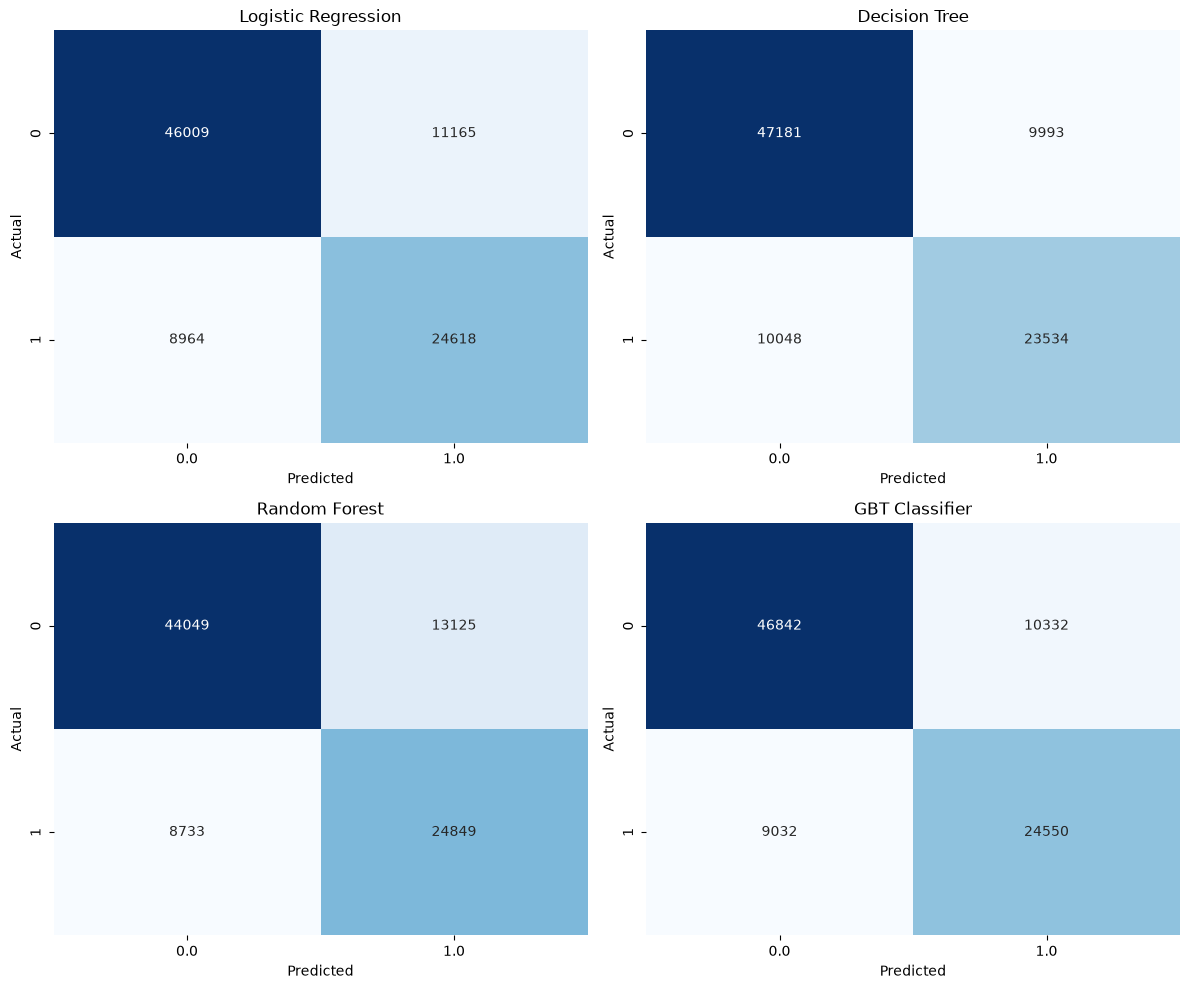

In [12]:
# 12. Confusion Matrix Analysis | Phân tích ma trận nhầm lẫn

print("\n" + "=" * 60)
print("12. CONFUSION MATRIX ANALYSIS")
print("=" * 60)

preds_list = [
    ("Logistic Regression", lr_preds),
    ("Decision Tree", dt_preds),
    ("Random Forest", rf_preds),
    ("GBT Classifier", gbt_preds)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (name, preds) in enumerate(preds_list):

    ax = axes.flatten()[i]

    cm = (
        preds.groupBy("label", "prediction")
             .count()
             .toPandas()
             .pivot(index="label", columns="prediction", values="count")
             .fillna(0)
    )

    sns.heatmap(cm,annot=True,fmt="g",cmap="Blues",cbar=False,ax=ax)

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


13. ROC-AUC COMPARISON


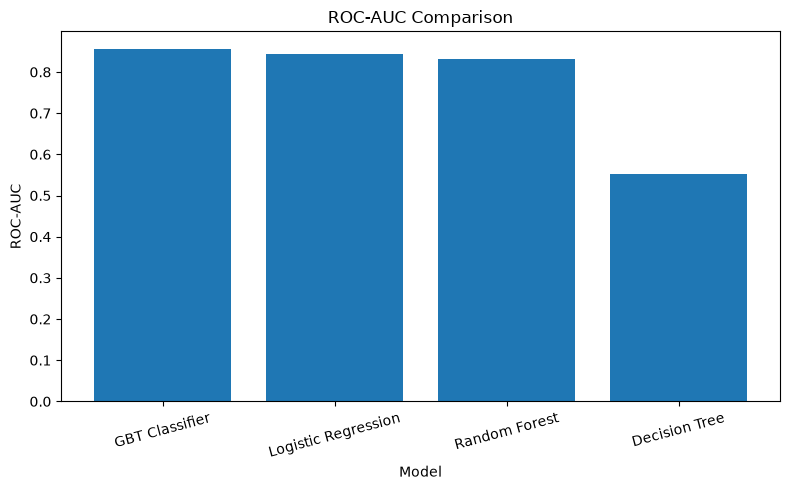

In [13]:
# 13. ROC-AUC Comparison | So sánh ROC-AUC giữa các mô hình

print("\n" + "=" * 60)
print("13. ROC-AUC COMPARISON")
print("=" * 60)

roc_results = df_metrics.sort_values("ROC-AUC",ascending=False)

plt.figure(figsize=(8,5))
plt.bar(roc_results["Model"],roc_results["ROC-AUC"])
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("ROC-AUC Comparison")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [14]:
# 14. Model Ranking & Final Selection | Xếp hạng mô hình

print("\n" + "=" * 60)
print("14. MODEL RANKING & FINAL SELECTION")
print("=" * 60)

df_metrics = df_metrics.sort_values("ROC-AUC",ascending=False).reset_index(drop=True)

df_metrics["Rank"] = df_metrics.index + 1
best_model = df_metrics.iloc[0]

with open(BEST_MODEL_PATH, "w") as f:
    f.write(best_model["Model"])

print(f"Selected Best Model : {best_model['Model']}")
print(f"ROC-AUC             : {best_model['ROC-AUC']:.4f}")
print(f"Saved To            : {BEST_MODEL_PATH}")


14. MODEL RANKING & FINAL SELECTION
Selected Best Model : GBT Classifier
ROC-AUC             : 0.8560
Saved To            : ../models/best_model.txt


In [15]:
# 15. Evaluation Summary | Tổng kết đánh giá

print("\n" + "=" * 60)
print("15. EVALUATION SUMMARY")
print("=" * 60)
print("Status: Evaluation completed successfully.")
print("Next: Notebook 06 — Model Interpretation.")


15. EVALUATION SUMMARY
Status: Evaluation completed successfully.
Next: Notebook 06 — Model Interpretation.
